# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:**  İlyas Bora Altun
**Student ID:** 2020403018

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [2]:
# Load the dataset from the midterm data folder
data_path = "data/electrical_grid_stability.csv"
df = pd.read_csv(data_path)

original_features = [f"tau{i}" for i in range(1, 5)]
original_features += [f"p{i}" for i in range(1, 5)]
original_features += [f"g{i}" for i in range(1, 5)]

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (10000, 14)


In [3]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values by column:")
print(df.isna().sum())

print("\nSummary statistics for numeric columns:")
display(df.describe())

print("\nTarget value counts:")
print(df["stabf"].value_counts())

Shape: (10000, 14)

Data types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

First 5 rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



Missing values by column:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Summary statistics for numeric columns:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403



Target value counts:
stabf
unstable    6380
stable      3620
Name: count, dtype: int64


---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [4]:
df["is_unstable"] = (df["stabf"] == "unstable").astype(int)
df["total_reaction_time"] = df[["tau1", "tau2", "tau3", "tau4"]].sum(axis=1)
df["power_imbalance"] = df[["p1", "p2", "p3", "p4"]].sum(axis=1)
df["avg_elasticity"] = df[["g1", "g2", "g3", "g4"]].mean(axis=1)

display(
    df[["stabf", "is_unstable", "total_reaction_time", "power_imbalance", "avg_elasticity"]].head()
)

,stabf,is_unstable,total_reaction_time,power_imbalance,avg_elasticity
0,unstable,1,24.200725,-2.886580e-15,0.838878
1,stable,0,18.623519,-6.661338e-16,0.654938
2,unstable,1,22.081132,0.000000e+00,0.469757
3,unstable,1,15.213218,-9.992007e-16,0.678763
4,unstable,1,25.544216,4.996004e-15,0.682607


In [5]:
class_counts = df["stabf"].value_counts().rename("count")
class_percentages = (df["stabf"].value_counts(normalize=True) * 100).round(2).rename("percentage")
class_balance = pd.concat([class_counts, class_percentages], axis=1)

display(class_balance)

,count,percentage
stabf,,
unstable,6380,63.8
stable,3620,36.2


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [6]:
grouped_means = df.groupby("stabf")[original_features].mean().round(4)
mean_differences = (
    (grouped_means.loc["unstable"] - grouped_means.loc["stable"])
    .abs()
    .sort_values(ascending=False)
)

print("Grouped means by stability class:")
display(grouped_means)

print("Absolute mean differences (largest first):")
display(mean_differences.to_frame("absolute_difference"))

print(
    "The largest differences appear in the reaction-time variables, especially tau2, tau4, tau3, and tau1. "
    "Elasticity variables are the next strongest separators, while the power variables differ only slightly between the two groups."
)

Grouped means by stability class:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
stabf,,,,,,,,,,,,
stable,4.3948,4.3534,4.3854,4.3785,3.7401,-1.2535,-1.2496,-1.2369,0.4530,0.4459,0.4406,0.4504
unstable,5.7352,5.7588,5.7406,5.7445,3.7556,-1.2480,-1.2502,-1.2574,0.5658,0.5699,0.5729,0.5673


Absolute mean differences (largest first):


,absolute_difference
tau2,1.4054
tau4,1.3660
tau3,1.3552
tau1,1.3404
g3,0.1323
g2,0.1240
g4,0.1169
g1,0.1128
p4,0.0205
p1,0.0155


The largest differences appear in the reaction-time variables, especially tau2, tau4, tau3, and tau1. Elasticity variables are the next strongest separators, while the power variables differ only slightly between the two groups.


In [7]:
stab_correlations = (
    df[original_features + ["stab"]]
    .corr(numeric_only=True)["stab"]
    .drop("stab")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top3_corr = stab_correlations.head(3)

print("Correlation of each feature with the continuous stability measure (stab):")
display(stab_correlations.to_frame("correlation_with_stab"))

print("Top 3 features by absolute correlation with stab:")
display(top3_corr.to_frame("correlation_with_stab"))

Correlation of each feature with the continuous stability measure (stab):


,correlation_with_stab
g3,0.308235
g2,0.293601
tau2,0.290975
g1,0.282774
tau3,0.280700
g4,0.279214
tau4,0.278576
tau1,0.275761
p4,-0.020786
p1,0.010278


Top 3 features by absolute correlation with stab:


,correlation_with_stab
g3,0.308235
g2,0.293601
tau2,0.290975


In [8]:
unstable_tau1 = df.loc[df["stabf"] == "unstable", "tau1"]

print(f"Unstable tau1 minimum: {unstable_tau1.min():.4f}")
print(f"Unstable tau1 maximum: {unstable_tau1.max():.4f}")
print(f"Unstable tau1 mean: {unstable_tau1.mean():.4f}")

Unstable tau1 minimum: 0.5013
Unstable tau1 maximum: 9.9995
Unstable tau1 mean: 5.7352


In [9]:
g1_stats = df.groupby("stabf")["g1"].agg(["mean", "std"]).round(4)

display(g1_stats)

print(
    "Producer elasticity is higher on average in unstable grids (0.5658 vs 0.4530), "
    "while the spread is fairly similar in the two groups."
)

,mean,std
stabf,,
stable,0.4530,0.2653
unstable,0.5658,0.2709


Producer elasticity is higher on average in unstable grids (0.5658 vs 0.4530), while the spread is fairly similar in the two groups.


---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

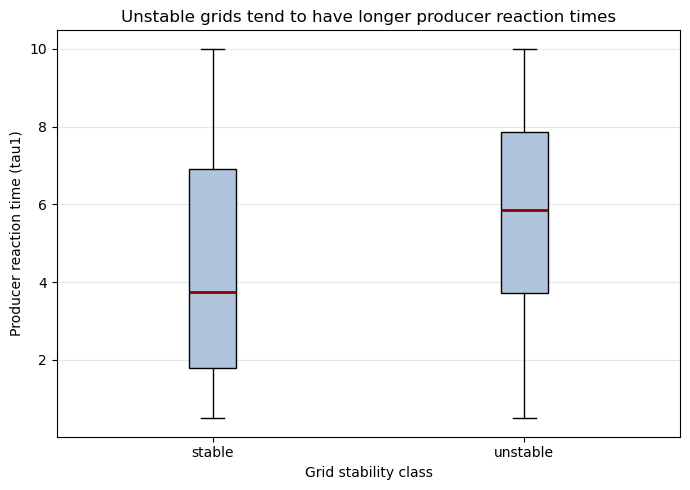

In [10]:
plt.figure(figsize=(7, 5))
box_data = [
    df.loc[df["stabf"] == "stable", "tau1"],
    df.loc[df["stabf"] == "unstable", "tau1"],
]

plt.boxplot(
    box_data,
    tick_labels=["stable", "unstable"],
    patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue"),
    medianprops=dict(color="darkred", linewidth=2),
)
plt.xlabel("Grid stability class")
plt.ylabel("Producer reaction time (tau1)")
plt.title("Unstable grids tend to have longer producer reaction times")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

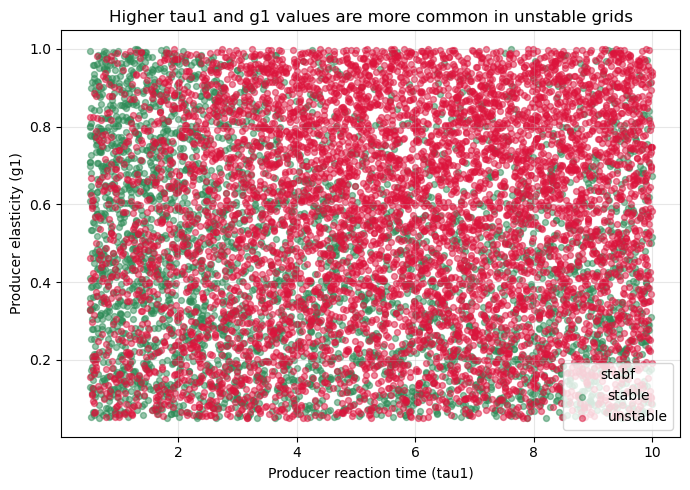

In [11]:
plt.figure(figsize=(7, 5))
colors = {"stable": "seagreen", "unstable": "crimson"}

for label, color in colors.items():
    subset = df[df["stabf"] == label]
    plt.scatter(
        subset["tau1"],
        subset["g1"],
        label=label,
        color=color,
        alpha=0.5,
        s=18,
    )

plt.xlabel("Producer reaction time (tau1)")
plt.ylabel("Producer elasticity (g1)")
plt.title("Higher tau1 and g1 values are more common in unstable grids")
plt.legend(title="stabf")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

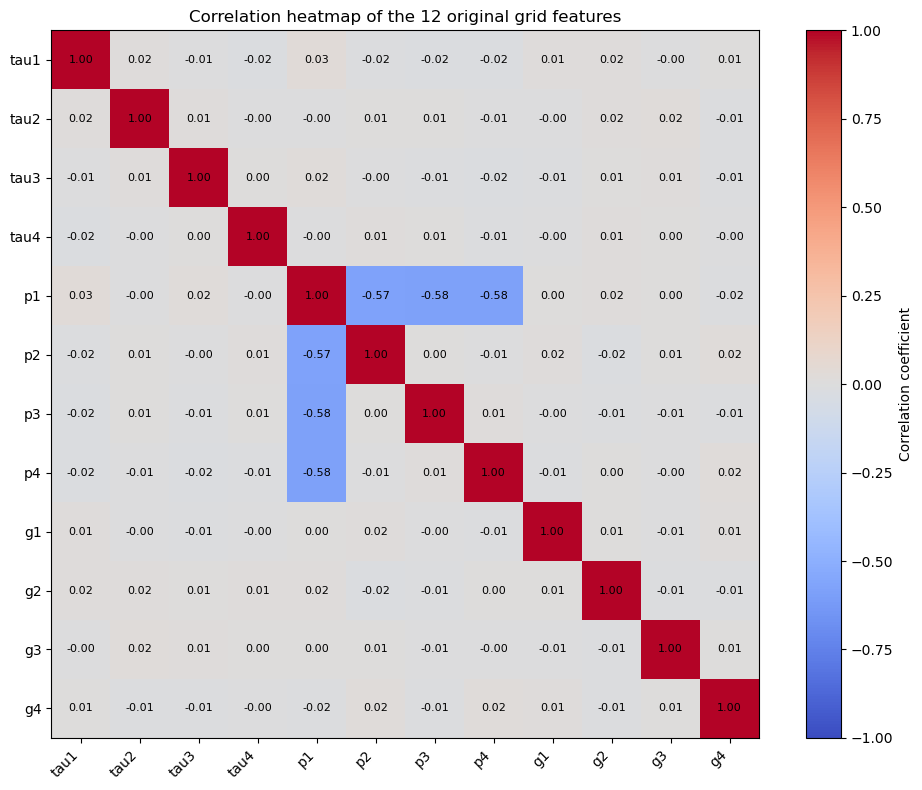

In [12]:
corr_matrix = df[original_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(original_features)))
ax.set_xticklabels(original_features, rotation=45, ha="right")
ax.set_yticks(range(len(original_features)))
ax.set_yticklabels(original_features)
ax.set_title("Correlation heatmap of the 12 original grid features")

for i in range(len(original_features)):
    for j in range(len(original_features)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation coefficient")
plt.tight_layout()
plt.show()

---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [13]:
tau1_z_scores = stats.zscore(df["tau1"])
tau1_outliers = df.loc[np.abs(tau1_z_scores) > 2, ["tau1", "stabf"]].copy()

print(f"Number of tau1 samples with |z| > 2: {len(tau1_outliers)}")
display(tau1_outliers.head(10))

Number of tau1 samples with |z| > 2: 0


,tau1,stabf


In [14]:
tau1_stable = df.loc[df["stabf"] == "stable", "tau1"]
tau1_unstable = df.loc[df["stabf"] == "unstable", "tau1"]

t_stat, p_value = stats.ttest_ind(tau1_stable, tau1_unstable, equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

t-statistic: -23.3033
p-value: 1.3928e-115


### Interpretation

**H0:** The mean `tau1` value is the same for stable and unstable grids.  
**H1:** The mean `tau1` value is different for stable and unstable grids.  
**Result:** The two-sample t-test gives `t = -23.3033` and `p = 1.39e-115`, which is far below `alpha = 0.05`. Therefore, I reject the null hypothesis and conclude that producer reaction time differs significantly between stable and unstable grids. In this dataset, unstable grids have a noticeably higher average `tau1`.  

**Most predictive feature:** `g3` appears to be the strongest single predictor so far because it has the highest absolute correlation with the continuous stability measure, `|corr(g3, stab)| = 0.3082`. The reaction-time features are also strong, but `g3` is the top feature by this correlation-based comparison.

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [15]:
X = df[original_features]
y = df["is_unstable"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (8000, 12)
Test set shape: (2000, 12)


In [16]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")

cm_df = pd.DataFrame(
    cm,
    index=["Actual stable", "Actual unstable"],
    columns=["Predicted stable", "Predicted unstable"],
)

print("\nConfusion matrix:")
display(cm_df)

Accuracy:  0.8200
Precision: 0.8408
Recall:    0.8856
F1 score:  0.8626

Confusion matrix:


,Predicted stable,Predicted unstable
Actual stable,510,214
Actual unstable,146,1130


---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

A **false stable** prediction is more dangerous because it would allow an actually unstable grid configuration to be treated as safe, increasing the risk of blackouts, equipment damage, or cascading failures. A **false unstable** prediction is still costly, but it is generally a safer mistake because operators can investigate or apply preventive controls. For this reason, **recall** for the `unstable` class should be prioritized so that truly risky cases are missed as rarely as possible.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

No, correlation does not prove causation. **Correlation** means two variables move together in the data, while **causation** means one variable directly produces a change in the other. A confounding-variable example here would be an overall “stressful operating regime” in which several reaction times and elasticity values are all high at the same time; in that case, `tau1` might look strongly related to instability even if the deeper cause is the broader combination of slow reactions and unfavorable elasticity across the whole grid.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr